In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import anndata as ad
from kneed import KneeLocator
import scipy.sparse as sp

In [2]:
# ! pip install kneed

In [3]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
ncells = 6

### 1. Select the guides for analysis

In [5]:

pert_type = "crispra"  # or "crispri"

# read in /home/user/Documents/Githubs/PerturbVAE_lingting/sherlock/notebooks/gbm/guides_over_50_DEGs.csv
guides_over_50 = pd.read_csv('guides_over_50_DEGs.csv')['guide'].tolist()

### 2. Prepare TCDG files

In [6]:
df = pd.read_csv(f'/home/user/Documents/Kinase_project/figures/decipher_analysis/NTC_{pert_type}/T_cell_dose_gene.csv')
T_cell_dose_gene = df['gene_short_name']

In [7]:
T_cell_dose_gene

0           TSPAN6
1              CFH
2             GCLC
3           NIPAL3
4            ENPP4
           ...    
3953    AC104662.2
3954          CDR1
3955    AC116366.3
3956    AC004922.1
3957    AC119674.2
Name: gene_short_name, Length: 3958, dtype: object

### 3. Generate raw and hvg files

In [8]:
gbm= ad.read_h5ad(f'/home/user/Documents/Kinase_project/{pert_type}_final/preprocessed_cds_without_Tcells.h5ad')

In [9]:
gbm

AnnData object with n_obs × n_vars = 317405 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [10]:
# Filter out cells where sgRNA is NA
gbm = gbm[~gbm.obs['sgRNA'].isna()].copy()
gbm

AnnData object with n_obs × n_vars = 317405 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [11]:
gbm.X.max()

4161.0

In [12]:
gbm_crop = gbm[
    (gbm.obs['total_sgrna_read_per_cell'] > 3) & 
    (gbm.obs['top_proportion'] > 0.3)
].copy()
gbm_crop

AnnData object with n_obs × n_vars = 258817 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster'
    var: 'features'

In [13]:
# Quality filter
gbm_crop = gbm_crop[
    (gbm_crop.obs['total_hash_umis_per_cell_ID'] > 1) &
    (gbm_crop.obs['top_to_second_best_ratio'] > 2)
].copy()

In [14]:
filtered_gbm_crop = gbm_crop[gbm_crop.obs['gene_id'].isin(guides_over_50+['NTC'])]
print("Filtered gene IDs:", filtered_gbm_crop.obs['gene_id'].unique())

Filtered gene IDs: ['NTC' 'TYK2' 'BMPR1A' 'EPHB4' 'PRKG2' 'MAP4K3' 'RIOK2' 'FGFR2' 'CDK4'
 'CDK2' 'CSNK2A1' 'DAPK2' 'CSNK1G1' 'PNCK' 'MAP3K5' 'WNK3' 'PRKACG' 'SMG1'
 'MOS' 'DAPK3' 'ADCK3' 'NEK9' 'MASTL' 'PDK3' 'EIF2AK1' 'TLK2' 'CDK8'
 'AURKA' 'CDK12' 'CDK11A' 'JAK1' 'PRKDC' 'ATR' 'TSSK4' 'STYK1' 'BRDT'
 'PLK3' 'ROS1' 'EIF2AK2' 'ANKK1' 'NRBP1' 'RPS6KC1' 'RIPK2' 'BCR' 'ABL1'
 'PDGFRA' 'PRKCG' 'PIK3C2A' 'MAP3K14' 'ALK' 'NEK4' 'NTRK3' 'MAPK11' 'KDR'
 'NLK' 'PKMYT1' 'C9orf96' 'AXL' 'TRIM33' 'CDKL2' 'MET' 'STK35' 'EPHB2'
 'PIM2' 'PRPF4B' 'CDC42BPA' 'WEE1' 'SRPK3' 'EPHA2' 'PRKD3' 'NPR2' 'PIK3CB']


In [15]:
gene_id_counts = filtered_gbm_crop.obs['gene_id'].value_counts()
gene_id_counts

gene_id
NTC       14492
MAP3K5      414
EPHB4       361
BCR         354
ANKK1       325
          ...  
PDGFRA      161
TRIM33      159
PKMYT1      149
MAP4K3      134
EPHA2       133
Name: count, Length: 72, dtype: int64

In [16]:
filtered_gbm_crop.obs['gene_id'].value_counts()[1]

/tmp/ipykernel_220879/4042227815.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  filtered_gbm_crop.obs['gene_id'].value_counts()[1]


414

In [17]:
# Filter NTC cells
ntc_cells = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] == 'NTC']

# Randomly sample NTC cells (Top kinases gene count)
ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=SEED).index
ntc_sampled_adata = filtered_gbm_crop[filtered_gbm_crop.obs.index.isin(ntc_sampled_indices)].copy()

# Filter out NTC cells from the original data to get non-NTC data
non_ntc_adata = filtered_gbm_crop[filtered_gbm_crop.obs['gene_id'] != 'NTC']

# Combine sampled NTC cells with non-NTC data
combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)
combined_adata

/tmp/ipykernel_220879/3719994924.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ntc_sampled_indices = ntc_cells.obs.sample(n=filtered_gbm_crop.obs['gene_id'].value_counts()[1], random_state=SEED).index
/tmp/ipykernel_220879/3719994924.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = ntc_sampled_adata.concatenate(non_ntc_adata)


AnnData object with n_obs × n_vars = 17347 × 56648
    obs: 'P7', 'P5', 'sample', 'n.umi', 'log10.umi', 'percent_mito', 'cell_ID', 'RT', 'Lig', 'new_cell', 'oligo', 'total_reads.x', 'total_hash_umis_per_cell_ID', 'top_to_second_best_ratio', 'treatment', 'sgRNA', 'total_reads.y', 'sgRNA_proportion', 'total_sgrna_read_per_cell', 'rank', 'top_to_second', 'second_to_third', 'third_to_next', 'top_proportion', 'second_proportion', 'third_proportion', 'top_sg', 'second_sg', 'third_sg', 'gene', 'second_sg_gene', 'third_sg_gene', 'cell', 'RT_lig', 'num_genes_expressed', 'Size_Factor', 'gene_id', 'oligo_cleaned', 'replicate', 'g1s_score', 'g2m_score', 'proliferation_index', 'dose', 'UMAP1', 'UMAP2', 'PCA_Cluster', 'batch'
    var: 'features'

In [18]:
combined_adata.obs['gene_id'].value_counts()

gene_id
MAP3K5    414
NTC       414
EPHB4     361
BCR       354
ANKK1     325
         ... 
PDGFRA    161
TRIM33    159
PKMYT1    149
MAP4K3    134
EPHA2     133
Name: count, Length: 72, dtype: int64

In [19]:
combined_adata.obs['treatment']        = combined_adata.obs['dose'].replace({1.: '1to1', 0.5: '1to0.5', 0.25: '1to0.25', 0.: 'Untreated'})
combined_adata.obs['treatment_geneid'] = combined_adata.obs['treatment'].astype(str) + '_' + combined_adata.obs['gene_id'].astype(str)

In [20]:
def make_metacells_bootstrap(adata, groupby='treatment_geneid', n_cells=10,
                              n_metacells=30, seed=42, layer=None):
    """Bootstrap metacells: sample n_cells without replacement, n_metacells times per group."""
    X = adata.layers[layer] if layer else adata.X
    if sp.issparse(X):
        X = X.toarray()
    rng = np.random.default_rng(seed)
    rows, obs_records = [], []
    for _, grp in adata.obs.groupby(groupby):
        cell_idx = [adata.obs_names.get_loc(i) for i in grp.index]
        if len(cell_idx) < n_cells:
            continue
        for _ in range(n_metacells):
            sampled = rng.choice(cell_idx, size=n_cells, replace=False)
            rows.append(X[sampled].sum(axis=0))
            meta = {col: grp[col].iloc[0] for col in ['gene_id', 'treatment', 'treatment_geneid', 'dose']}
            meta['n_cells_summed'] = n_cells
            obs_records.append(meta)
    return ad.AnnData(
        X=np.vstack(rows),
        obs=pd.DataFrame(obs_records).reset_index(drop=True),
        var=adata.var.copy()
    )

In [21]:
adata_meta = make_metacells_bootstrap(combined_adata, groupby='treatment_geneid', n_cells=ncells , n_metacells=30, seed=SEED)
print(adata_meta)
print(adata_meta.obs['treatment_geneid'].value_counts())

AnnData object with n_obs × n_vars = 8640 × 56648
    obs: 'gene_id', 'treatment', 'treatment_geneid', 'dose', 'n_cells_summed'
    var: 'features'
treatment_geneid
Untreated_MAP4K3    30
Untreated_MAPK11    30
Untreated_MASTL     30
Untreated_MET       30
Untreated_MOS       30
                    ..
1to0.25_ANKK1       30
1to0.25_ATR         30
1to0.25_AURKA       30
1to0.25_AXL         30
1to0.25_BCR         30
Name: count, Length: 288, dtype: int64


/home/user/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [22]:
# Use only untreated cells for DEG
untreated_cells = adata_meta[adata_meta.obs['treatment'] == 'Untreated'].copy()

In [23]:
sc.pp.normalize_total(untreated_cells)
sc.pp.log1p(untreated_cells)

sc.tl.rank_genes_groups(
    untreated_cells, groupby='gene_id', reference='NTC',
    use_raw=False, method='wilcoxon'
)
print('DEG done.')

/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/user/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarning: DataFrame is highly fragmente

DEG done.


In [24]:
deg_df = sc.get.rank_genes_groups_df(untreated_cells, group=None, key='rank_genes_groups')

sig_raw = deg_df[deg_df['pvals'] < 0.05].sort_values(['group', 'pvals']).reset_index(drop=True)
sig_adj = deg_df[deg_df['pvals_adj'] < 0.05].sort_values(['group', 'pvals_adj']).reset_index(drop=True)

print(f'DEGs (raw p<0.05):  {len(sig_raw["names"].unique())} unique genes, {sig_raw["group"].nunique()} perturbations')
print(f'DEGs (FDR<0.05):    {len(sig_adj["names"].unique())} unique genes, {sig_adj["group"].nunique()} perturbations')

DEGs (raw p<0.05):  13524 unique genes, 71 perturbations
DEGs (FDR<0.05):    2068 unique genes, 69 perturbations


In [25]:
# DEG count per perturbation (FDR < 0.05)
deg_counts = sig_adj.groupby('group', observed=True).size().sort_values(ascending=False)
print('DEG count per perturbation (FDR<0.05):')
print(deg_counts.to_string())

DEG count per perturbation (FDR<0.05):
group
EPHA2       364
PKMYT1      224
MAP4K3      185
PRKD3       160
ROS1        157
AXL         157
PIK3C2A     155
KDR         148
EPHB2       112
BMPR1A      104
WNK3         92
PRKDC        90
PDGFRA       86
CDC42BPA     85
PIK3CB       82
CDK2         78
NRBP1        78
SRPK3        75
ADCK3        62
STYK1        53
RIOK2        52
C9orf96      51
PNCK         49
JAK1         47
EIF2AK2      41
CDK12        40
NEK4         40
CDK11A       40
TRIM33       40
CSNK1G1      37
PRKACG       33
DAPK3        32
WEE1         31
EIF2AK1      30
CSNK2A1      28
PDK3         27
ANKK1        27
PRPF4B       26
MET          26
MASTL        26
MAP3K14      25
PRKCG        24
PIM2         23
CDKL2        22
NEK9         21
BRDT         18
FGFR2        18
TSSK4        17
MOS          16
SMG1         15
CDK4         14
ALK          12
STK35        10
TYK2          9
RPS6KC1       8
NTRK3         7
PRKG2         7
CDK8          5
TLK2          4
MAP3K5     

In [26]:
# How many perturbations have at least 1 DEG?
n_with_degs = (deg_counts > 0).sum()
total_perts = untreated_cells.obs['gene_id'].nunique() - 1  # exclude NTC
print(f'Perturbations with >=1 DEG (FDR<0.05): {n_with_degs} / {total_perts}')
print(f'Perturbations with >=5 DEGs:           {(deg_counts >= 5).sum()} / {total_perts}')
print(f'Perturbations with >=10 DEGs:          {(deg_counts >= 10).sum()} / {total_perts}')

Perturbations with >=1 DEG (FDR<0.05): 69 / 71
Perturbations with >=5 DEGs:           58 / 71
Perturbations with >=10 DEGs:          53 / 71


In [27]:
sig_adj

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ADCK3,DIEXF,-5.913770,-4.600970,3.343644e-09,0.000189
1,ADCK3,CLEC11A,5.507198,3.246395,3.645891e-08,0.001033
2,ADCK3,ZNF33B,-5.144980,-3.430985,2.675492e-07,0.003031
3,ADCK3,ZNF782,-5.159764,-2.620866,2.472607e-07,0.003031
4,ADCK3,KLF12,-5.218902,-0.895006,1.799868e-07,0.003031
...,...,...,...,...,...,...
3571,WNK3,SNTB1,3.969618,2.253206,7.198788e-05,0.046341
3572,WNK3,SCFD2,-3.962226,-0.646266,7.425420e-05,0.047262
3573,WNK3,TSNAX,3.947442,1.295015,7.899078e-05,0.048638
3574,WNK3,UBE2D3,-3.947442,-0.588562,7.899078e-05,0.048638


In [28]:
# Top 50 DEGs (by FDR) for guides with >50 significant DEGs
top50_deg_df = (
    sig_adj[sig_adj['group'].isin(guides_over_50)]
    .groupby('group', observed=True)
    .head(10)
)
print(top50_deg_df.groupby('group', observed=True).size().to_string())

group
ADCK3       10
ALK         10
ANKK1       10
ATR          1
AURKA        4
AXL         10
BCR          3
BMPR1A      10
BRDT        10
C9orf96     10
CDC42BPA    10
CDK2        10
CDK4        10
CDK8         5
CDK11A      10
CDK12       10
CDKL2       10
CSNK1G1     10
CSNK2A1     10
DAPK2        2
DAPK3       10
EIF2AK1     10
EIF2AK2     10
EPHA2       10
EPHB2       10
EPHB4        3
FGFR2       10
JAK1        10
KDR         10
MAP3K5       4
MAP3K14     10
MAP4K3      10
MAPK11       3
MASTL       10
MET         10
MOS         10
NEK4        10
NEK9        10
NLK          4
NRBP1       10
NTRK3        7
PDGFRA      10
PDK3        10
PIK3C2A     10
PIK3CB      10
PIM2        10
PKMYT1      10
PLK3         4
PNCK        10
PRKACG      10
PRKCG       10
PRKD3       10
PRKDC       10
PRKG2        7
PRPF4B      10
RIOK2       10
RIPK2        3
ROS1        10
RPS6KC1      8
SMG1        10
SRPK3       10
STK35       10
STYK1       10
TLK2         4
TRIM33      10
TSSK4       10
TYK2

In [29]:
len(top50_deg_df['names'].unique())

390

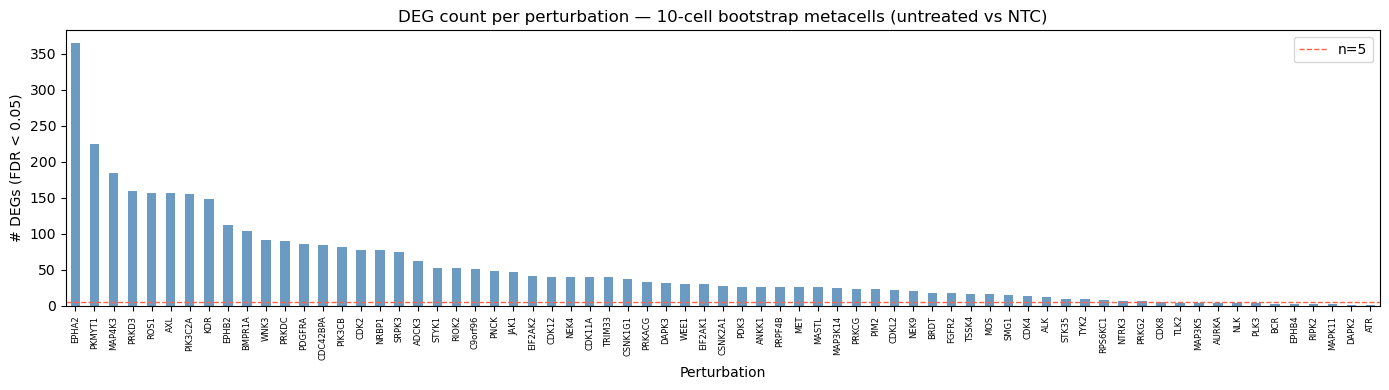

In [30]:
# Bar chart of DEG counts per perturbation
fig, ax = plt.subplots(figsize=(14, 4))
deg_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('Perturbation')
ax.set_ylabel('# DEGs (FDR < 0.05)')
ax.set_title('DEG count per perturbation — 10-cell bootstrap metacells (untreated vs NTC)')
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.axhline(5, color='tomato', lw=1, ls='--', label='n=5')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

In [31]:
import pyreadr
result = pyreadr.read_r('/home/user/Documents/Githubs/PerturbVAE/sherlock/datasets/gbm/KinMap_kinase_protein_to_gene_map.rds')
res = result[None]  # RDS files contain only one object, so we use None as key
res = res[res['gene_id'].isin(adata_meta.obs.gene_id.unique())]
kinase_names = res['gene_short_name']

In [32]:
deg_set = set(map(str, top50_deg_df['names']))
kinase_set = set(map(str, kinase_names))
#tcdg_set = set(map(str, T_cell_dose_gene))

union_set =  deg_set | kinase_set #| tcdg_set
union_list = sorted(union_set)

print(f"deg_genes:        {len(deg_set)} genes")
print(f"kinase_genes:     {len(set(kinase_names))} genes")
#print(f"T_cell_dose_genes: {len(tcdg_set)} genes")
print(f"union:            {len(union_set)} genes")

deg_genes:        390 genes
kinase_genes:     71 genes
union:            455 genes


In [33]:
combined_adata_tcdg = adata_meta[:, adata_meta.var['features'].isin(union_list)].copy()
combined_adata_tcdg

AnnData object with n_obs × n_vars = 8640 × 455
    obs: 'gene_id', 'treatment', 'treatment_geneid', 'dose', 'n_cells_summed'
    var: 'features'

In [34]:
combined_adata_tcdg.var.rename(columns={'_index':'index'},inplace=True)
combined_adata_tcdg.write_h5ad(f'/home/user/Documents/Githubs/PerturbVAE_lingting/sherlock/datasets/gbm/filtered_gbm_{pert_type}_crop_top_bootstrap_{ncells}.h5ad')

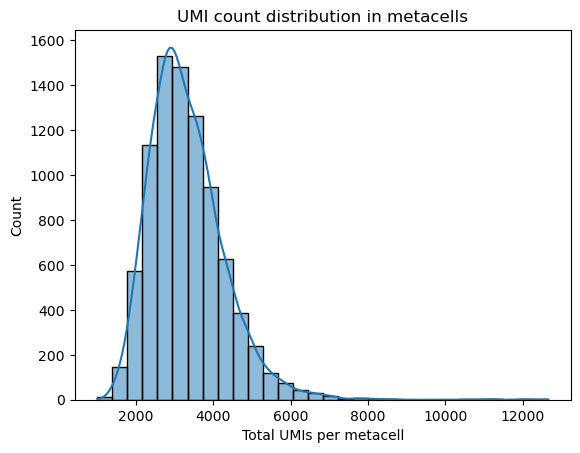

In [35]:
# what is the umi count distribution in the metacells?
combined_adata_tcdg.obs['total_umis'] = combined_adata_tcdg.X.sum(axis=1)
sns.histplot(combined_adata_tcdg.obs['total_umis'], bins=30, kde=True)
plt.xlabel('Total UMIs per metacell')
plt.title('UMI count distribution in metacells')
plt.show()

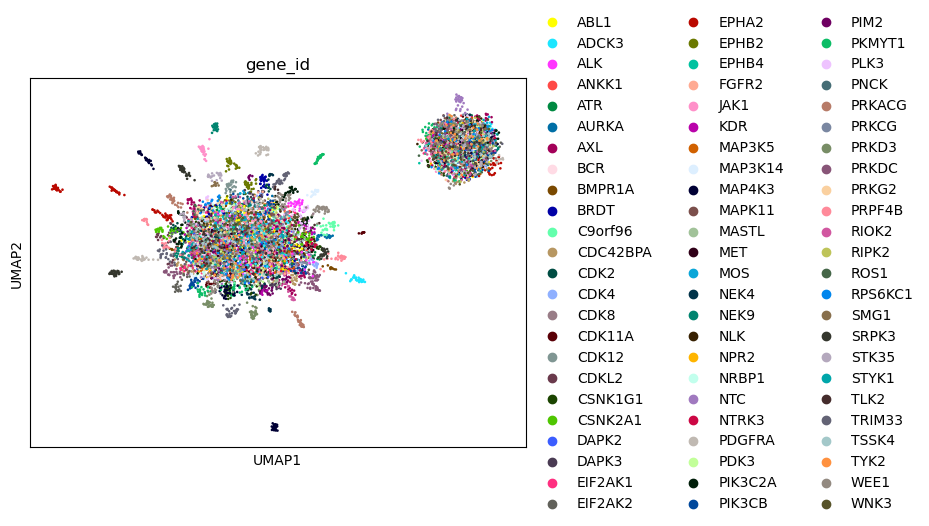

In [36]:
sc.pp.normalize_total(combined_adata_tcdg)
sc.pp.log1p(combined_adata_tcdg)
sc.pp.pca(combined_adata_tcdg, random_state=SEED)

sc.pp.neighbors(combined_adata_tcdg, random_state=SEED)
sc.tl.umap(combined_adata_tcdg, random_state=SEED)
sc.pl.umap(combined_adata_tcdg, color=['gene_id'])

In [37]:
combined_adata_tcdg.obs.dose = combined_adata_tcdg.obs.dose.astype(str)       

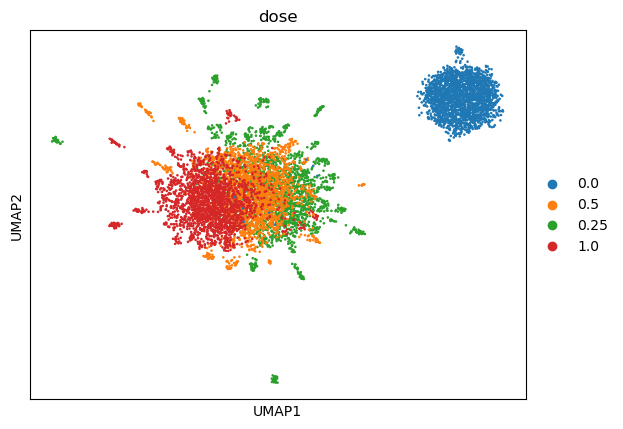

In [38]:
sc.pl.umap(combined_adata_tcdg, color=['dose'])